In [13]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from engine.EnvironmentState import EnvironmentState
from engine.CohortState import CohortState

    
def apply_global_warming(env_state: EnvironmentState, warming_rate: float = 0.05):
    """
    Simulates global warming by modifying the temperature layer in-place.
    """
    temp_grid = env_state.get_layer("temperature")
    
    # We use += for in-place memory efficiency. 
    # Let's add the baseline rate, plus a tiny bit of variance.
    variance = np.random.normal(loc=0.0, scale=0.01, size=env_state.shape)
    temp_grid += (warming_rate + variance)
    
# Initialize a 100x100 grid
world_shape = (180, 360)
env = EnvironmentState(world_shape)

# Create a latitudinal temperature gradient (e.g., 30C at equator, -20C at poles)
lats = np.linspace(-20, 30, world_shape[0]) 
gradient = np.tile(lats, (world_shape[1], 1)).T 
# Add random spatial noise
random_noise = np.random.normal(loc=0.0, scale=2.0, size=world_shape)

base_temperature = gradient + random_noise
env.add_layer("temperature", base_temperature)

In [3]:
class EcosystemModel:
    def __init__(self, env_state: EnvironmentState, cohorts: CohortState):
        self.env = env_state
        self.cohorts = cohorts
        
        self.env_processes = []
        self.bio_processes = [] # New list for biology
        
    def add_bio_process(self, process_func):
        self.bio_processes.append(process_func)
    def add_env_process(self, process_func):
        """Register a new environmental function to the pipeline."""
        self.env_processes.append(process_func)
        
    def step(self):
        # 1. Update Environment (e.g., Global Warming)
        for process in self.env_processes:
            process(self.env)
            
        # 2. Update Biology (e.g., Metabolism)
        for process in self.bio_processes:
            process(self.cohorts, self.env)
            
def seed_initial_cohorts(cohorts: CohortState, env_shape: tuple, num_cohorts: int = 5000):
    """
    Randomly generates initial cohorts and adds them to the state.
    """
    # Randomly assign locations across the 180x360 grid
    lats = np.random.randint(0, env_shape[0], size=num_cohorts)
    lons = np.random.randint(0, env_shape[1], size=num_cohorts)
    
    # Randomly assign masses (e.g., between 10g and 100,000g)
    masses = np.random.uniform(10.0, 100000.0, size=num_cohorts)
    
    # Smaller animals generally have higher abundances (inverse scaling)
    abundances = 1000000.0 / masses 
    
    # 80% herbivores (0), 20% carnivores (1)
    diets = np.random.choice([0, 1], size=num_cohorts, p=[0.8, 0.2])
    
    cohorts.add_cohorts(lats, lons, masses, abundances, diets)
    print(f"Successfully seeded {num_cohorts} cohorts into the world.")

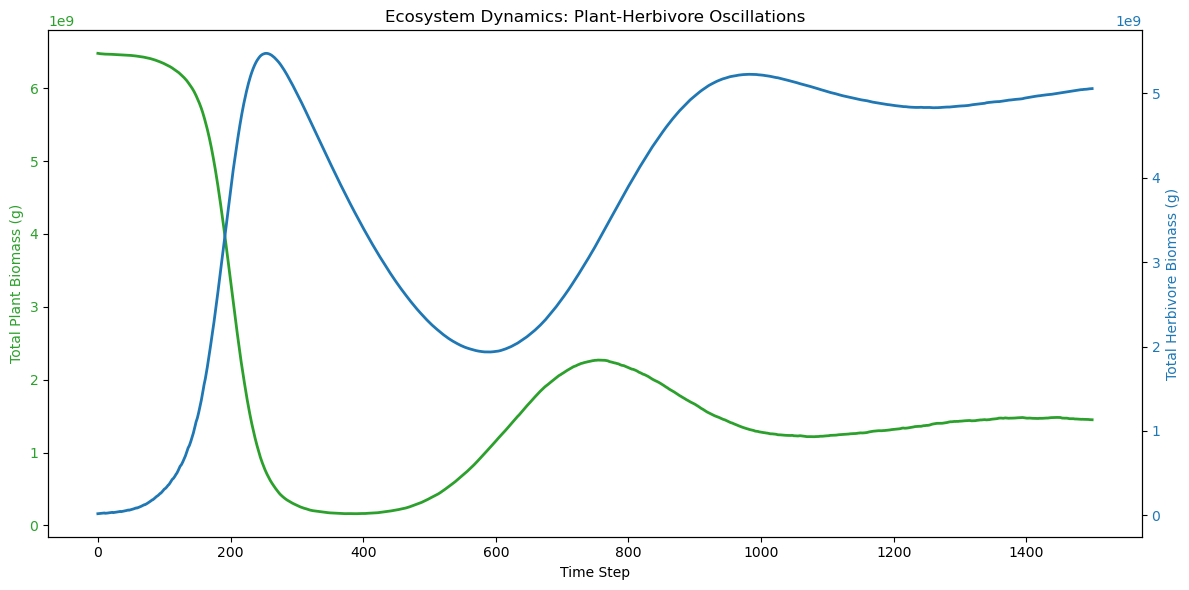

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from engine.processes import apply_metabolism, apply_vegetation_growth, apply_herbivory, apply_reproduction, apply_dispersal

# --- 1. Update the Seeder ---
def seed_initial_cohorts(cohorts: CohortState, env_shape: tuple, num_cohorts: int = 5000):
    lats = np.random.randint(0, env_shape[0], size=num_cohorts)
    lons = np.random.randint(0, env_shape[1], size=num_cohorts)
    
    # Assign genetics first
    adult_masses = np.random.uniform(50.0, 5000.0, size=num_cohorts)
    birth_masses = adult_masses * 0.10 # Babies are 10% of adult size
    
    # Start them off healthy (at exactly their adult mass)
    masses = adult_masses.copy() 
    abundances = 10000.0 / masses 
    diets = np.zeros(num_cohorts, dtype=np.int8) # ALL HERBIVORES for this test
    
    cohorts.add_cohorts(lats, lons, masses, abundances, diets, adult_masses, birth_masses)

# --- 2. Initialize World ---
world_shape = (180, 360) 
env = EnvironmentState(world_shape)
env.add_layer("temperature", np.full(world_shape, 20.0))
env.add_layer("carrying_capacity", np.full(world_shape, 100000.0)) # 100k grams of food per cell
env.add_layer("vegetation", np.full(world_shape, 100000.0))        # Start full

cohorts = CohortState(initial_capacity=500_000)
seed_initial_cohorts(cohorts, env.shape, num_cohorts=2000)

model = EcosystemModel(env, cohorts)
model.add_env_process(apply_vegetation_growth)
model.add_bio_process(apply_dispersal) # Let them walk around
model.add_bio_process(apply_metabolism) 
model.add_bio_process(apply_herbivory) # Then eat
model.add_bio_process(apply_reproduction)

# --- 3. Run the Simulation ---
num_steps = 1500
animal_biomass_history = []
plant_biomass_history = []

for tick in range(num_steps):
    model.step()
    
    # Merge cohorts every 5 steps to keep memory perfectly clean
    if tick % 5 == 0:
        model.cohorts.merge_cohorts()
    
    # Track Totals
    active = model.cohorts.is_active
    total_animal = np.sum(model.cohorts.body_mass[active] * model.cohorts.abundance[active]) if np.any(active) else 0
    total_plant = np.sum(model.env.get_layer("vegetation"))
    
    animal_biomass_history.append(total_animal)
    plant_biomass_history.append(total_plant)

# --- 4. Plot the Oscillations ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:green'
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Total Plant Biomass (g)', color=color)
ax1.plot(range(num_steps), plant_biomass_history, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Total Herbivore Biomass (g)', color=color)  
ax2.plot(range(num_steps), animal_biomass_history, color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ecosystem Dynamics: Plant-Herbivore Oscillations')
fig.tight_layout()  
plt.show()

# Engine V2

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from engine_v2.EcosystemEngine import EcosystemEngine
from engine_v2.EnvironmentState import EnvironmentState
from engine_v2.EcosystemGridState import EcosystemGridState
from engine_v2.SpeciesRegistry import SpeciesRegistry

from engine_v2.processes import apply_vegetation_growth, apply_atn_step, apply_dispersal
import numpy as np
world_shape = (180, 360) 
env = EnvironmentState(world_shape)
env.add_layer("temperature", np.full(world_shape, 20.0))
env.add_layer("carrying_capacity", np.full(world_shape, 100000.0))

# Create 3 species: 1 plant, 2 animals
registry = SpeciesRegistry(num_species=20)
registry.add_species_to_group(
    group_name="deciduous_trees", 
    species_indices=list(range(0, 5)), 
    params={
        "base_growth_rate": 0.15, 
        "mortality_rate": 0.05,
        "max_dispersal_rate": 0.01
    }
)

registry.add_species_to_group(
    group_name="coniferous_trees", 
    species_indices=list(range(10, 15)), 
    params={
        "base_growth_rate": 0.08, 
        "mortality_rate": 0.02,
        "max_dispersal_rate": 0.02
    }
)

registry.add_species_to_group(
    group_name="herbs", 
    species_indices=list(range(5, 10)), 
    params={
        "base_growth_rate": 0.2, 
        "mortality_rate": 0.1,
        "max_dispersal_rate": 0.05
    }
)
registry.add_species_to_group(
    group_name="herbivores", 
    species_indices=list(range(15, 18)), 
    params={
        "base_growth_rate": 0.1, 
        "mortality_rate": 0.05,
        "max_dispersal_rate": 0.1
    }
)
registry.add_species_to_group(
    group_name="carnivores", 
    species_indices=list(range(18, 20)), 
    params={
        "base_growth_rate": 0.05, 
        "mortality_rate": 0.02,
        "max_dispersal_rate": 0.2
    }
)

#bigger groups for more interesting dynamics
registry.add_species_to_group(group_name="vertebrates", species_indices=list(range(15, 20))) # All vertebrates for process targeting
registry.add_species_to_group(group_name="plants", species_indices=list(range(0, 15))) # All plants for process targeting

#add feeding links (plants -> herbivores -> carnivores)
registry.add_feeding_link("plants", "herbivores")
registry.add_feeding_link("herbivores", "carnivores")


#Grid state with 20 species (15 plants, 5 animals)
grid = EcosystemGridState(world_shape, registry)

# Seed initial biomass matrices directly
# Plant biomass starts at 50,000 across the whole grid
grid.add_layer("metabolic_loss")

# 2. Dispersal team says: "I need ATN to output net growth rates for us to read."
grid.add_layer("net_growth_rate")

# Seed the initial biomass 
grid.layers["biomass"][:, :, registry.get_group_indices("plants")] = 50000.0  # Plants
grid.layers["biomass"][:, :, registry.get_group_indices("animals")] = 5000.0  # Animals

# --- 2. Build the Engine ---
model = EcosystemEngine(grid, env)

# The order here defines the pipeline sequence
model.add_process(apply_vegetation_growth)
model.add_process(apply_atn_step)
model.add_process(apply_dispersal)

# --- 3. Run the Simulation ---
num_steps = 150
vertebrate_biomass_history = []
plant_biomass_history = []

for tick in range(num_steps):
    model.step()
    
    # Track Totals using the new matrix views
    # np.sum() cleanly aggregates the whole grid
    total_plant = np.sum(grid.get_layer_view("biomass", "plants"))
    total_vertebrates = np.sum(grid.get_layer_view("biomass", "vertebrates"))
    
    plant_biomass_history.append(total_plant)
    vertebrate_biomass_history.append(total_vertebrates)
    


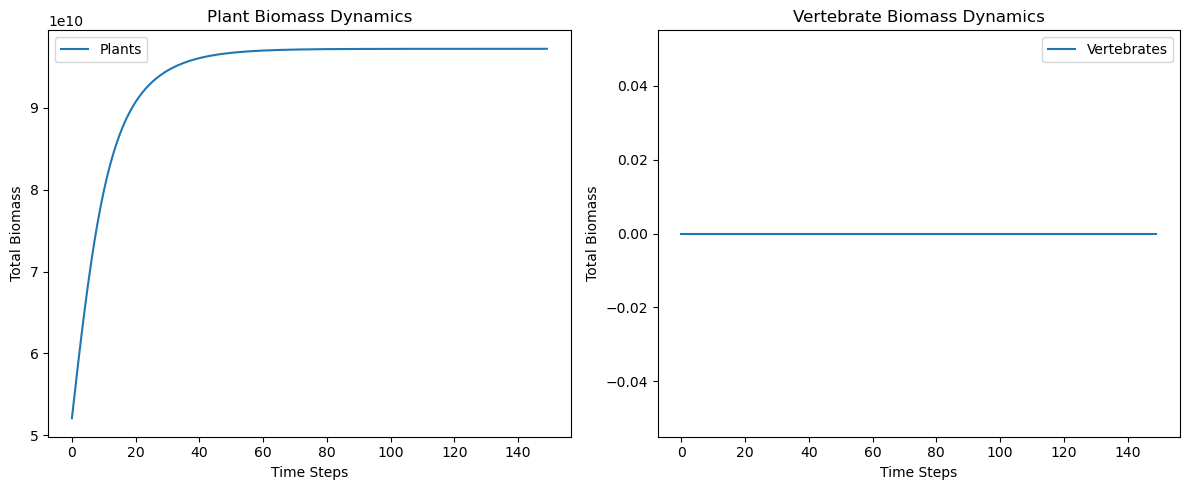

In [2]:
#plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(plant_biomass_history, label="Plants")
plt.xlabel("Time Steps")
plt.ylabel("Total Biomass")
plt.title("Plant Biomass Dynamics")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vertebrate_biomass_history, label="Vertebrates")
plt.xlabel("Time Steps")
plt.ylabel("Total Biomass")
plt.title("Vertebrate Biomass Dynamics")
plt.legend()

plt.tight_layout()
plt.show()